#Pytorch Workflow

lest explore a example pytorch end-to-end workflow

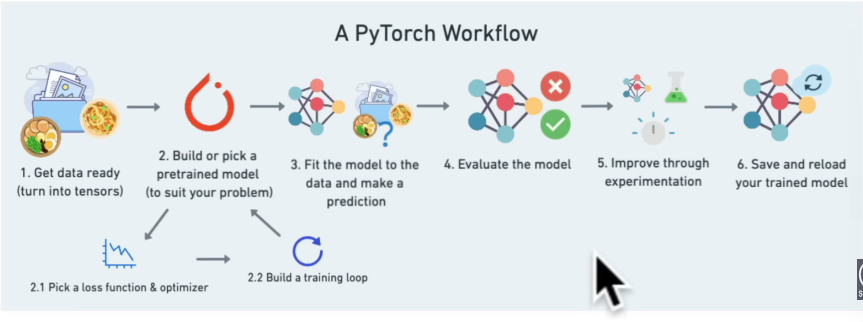

In [6]:
what_were_covering = {1: "data (prepare and load)",
                      2: "build model",
                      3: "fitting the model to data (training)",
                      4: "making predictions and evaluting a model (inference)",
                      5: "saving and loading a model",
                      6: "putting it all together"}

what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluting a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [7]:
import torch
from torch import nn #contains all building blocks
import matplotlib.pyplot as plt

torch.__version__

'2.13.0+cpu'

1) Data (preparing and loading)

Data can be almost anything... in machine learning.

    Excel speadsheet
    Images of any kind
    Videos (YouTube has lots of data...)
    Audio like songs or podcasts
    DNA
    Text

Machine learning is a game of two parts:

1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.

to showcase this , lets create some known data using linear regression formula
We will use a linear regression formula to make a st line with known **parameters**


In [8]:
#Create known parameters

weight = 0.7
bias = 0.3

#create
start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias

X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [9]:
len(X),len(y)

(50, 50)

### Splitting data into training and test sets (one of the most important concepts...)

Let's create a training and test set with our data.

In [10]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [11]:
def plot_prediction(train_data = X_train,
                    train_labels = y_train,
                    test_data = X_test,
                    test_labels = y_test,
                    predictions=None):


 #Plots training data,test data and compare dimesnions

  plt.figure(figsize=(10,7))

 #Plot training data in blue

  plt.scatter(train_data, train_labels,c = 'b',s=4 , label = "Training Data")

 #Plot test data in green
  plt.scatter(test_data, test_labels , c="g",s=4,label="Testing Data")

  #Are there predictions
  if predictions is not None:
    plt.scatter(test_data,predictions,c='red')

  #Show the Legend
  plt.legend(prop={'size':14})




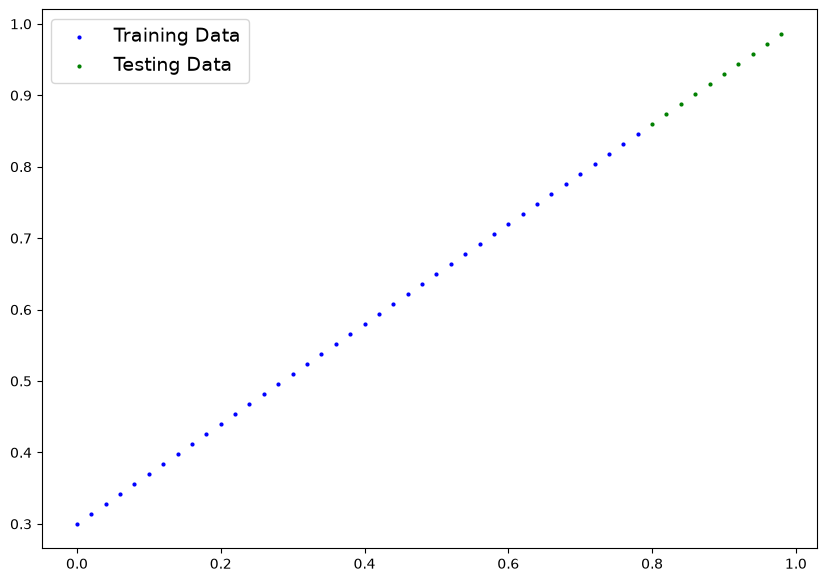

In [12]:
plot_prediction()

First model--
what our model does :
start with random values(weight and bias)
look at the training data and adjust the random values to better represent(or get closer to) the ideal value (the weight & bias value we used to create the data)


how does it do so
two main algorithms-
1) gradient descent
2) backpropagation


In [13]:
import torch
from torch import nn


# Blueprint for our model. Inheriting from nn.Module
class LinearRegressionModel(nn.Module):

   def __init__(self):

        # Let nn.Module run its own setup first
        super().__init__()

        self.weights = nn.Parameter(
            torch.randn(1,                    # one random starting number
                        dtype=torch.float32,  # store it as a 32-bit float
                        requires_grad=True)   # track it so it can learn
        )

        self.bias = nn.Parameter(
            torch.randn(1,                    # one random starting number
                        dtype=torch.float32,  # store it as a 32-bit float
                        requires_grad=True)   # track it so it can learn
        )

   def forward(self, x: torch.Tensor) -> torch.Tensor: #x is the input data

        # The straight-line formula: y = mx + c
        return self.weights * x + self.bias


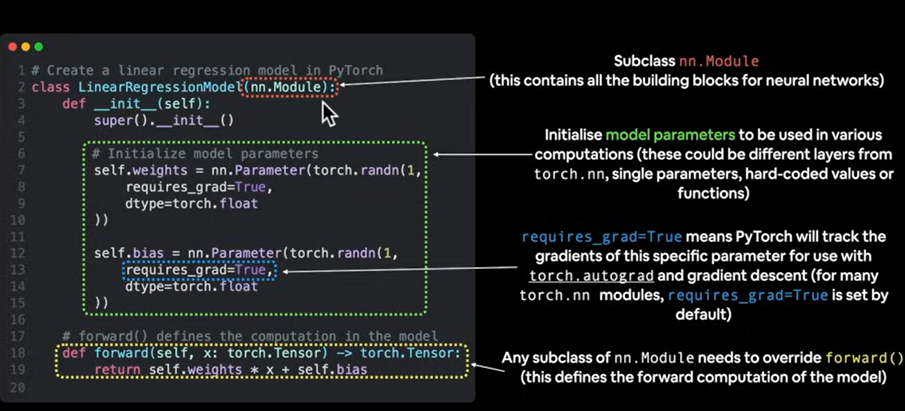

### Python model building essentials

* torch.nn - contains all of the building blocks for computational graphs
(another word for neural networks)

* torch.nn.parameters - what parameter should out model try and learn

* torch.nn.Module -  the abse class for a;; nn modules, if u subclass it,
you should overwrite forward

* torch.optim - this is where the optimizer in pytorch live,help in gradient descent

* def forward() - All nn.module subclass require u to overwrite forward

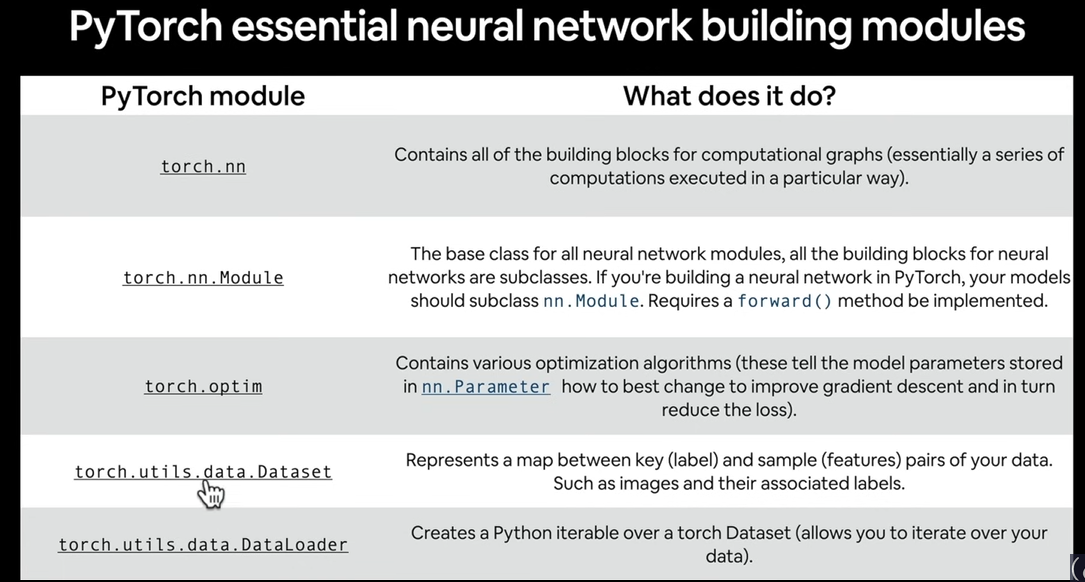

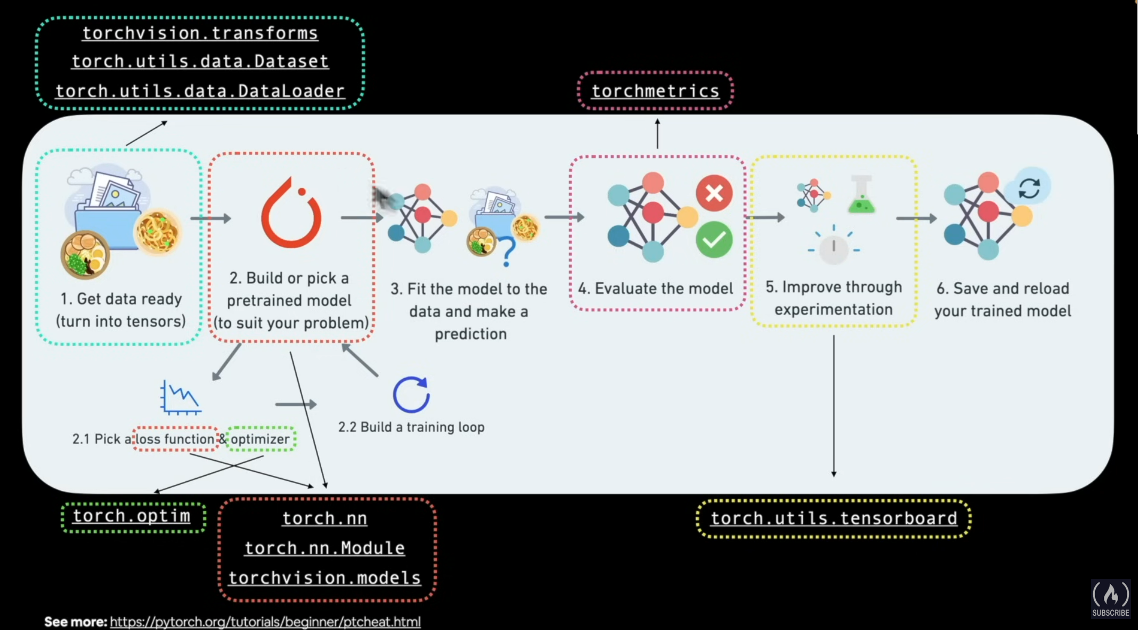

### checking the contents of our pytorch model

Whats inside

we can check our model parameters using .parameters()

In [14]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [15]:
#List name Parameters

model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [16]:
weight, bias

(0.7, 0.3)

#making pred using torch.inference_mode()

to check models predictive power,
lets see how well it predicts y_test based on X_test

In [17]:
X_test , y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [18]:
#make pred

with torch.inference_mode():
#make code faster, doesnt keep track of data
#can also use torch.no_grad():


    y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

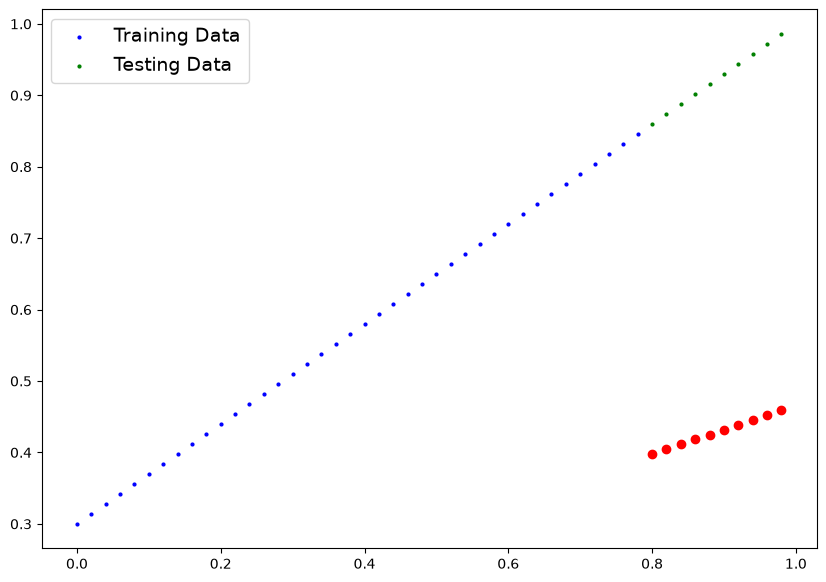

In [19]:
plot_prediction(predictions= y_preds)

In [20]:
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

## 3. Train model

The whole idea of training is for a model to move from some *unknown* parameters
(these may be random) to some *known* parameters.

Or in other words from a poor representation of the data to a better representation
of the data.

One way to measure how poor or how wrong your models predictions are is to use a
loss function.

* Note: Loss function may also be called cost function or criterion in different
areas. For our case, we're going to refer to it as a loss function.

Things we need to train:

* **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.
* **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight & bias in our case) to improve the loss function - https://pytorch.org/docs/stable/optim.html#module-torch.optim
    * Inside the optimizer you'll often have to set two parameters:
        * `params` - the model parameters you'd like to optimize, for example `params=model_0.parameters()`
        * `lr` (learning rate) - the learning rate is a hyperparameter that defines how big/small the optimizer changes the parameters with each step (a small `lr` results in small changes, a large `lr` results in large changes)

And specifically for PyTorch, we need:

* A training loop
* A testing loop

In [21]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [22]:
#Check out our model parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [23]:
#Setup a loss function
loss_fn = nn.L1Loss()

#Setup an Optimizer(stochastic gradient descent)

optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr=0.01)#IMP hyper parameter you can set


Q: Which loss function and optimizer should I use?

A: This will be problem specific. But with experience, you'll get an idea of what works and what doesn't with your particular problem set.

For example, for a regression problem (like ours), a loss function of `nn.L1Loss()` and an optimizer like `torch.optim.SGD()` will suffice.

But for a classification problem like classifying whether a photo is of a dog or a cat, you'll likely want to use a loss function of `nn.BCELoss()` (binary cross entropy loss).

### Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:

0. Loop through the data
1. Forward pass (this involves data moving through our model's `forward()` functions) to make predictions on data - also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss (**backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

In [24]:
torch.manual_seed(42)

epochs = 200

epoch_count = []
loss_values=[]
test_loss_values = []

for epoch in range(epochs):

    # Training mode
    model_0.train()

    # Forward pass
    y_pred = model_0(X_train)

    # Calculate training loss
    loss = loss_fn(y_pred, y_train)

    # Clear previous gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update model parameters
    optimizer.step()

    # Evaluation mode
    model_0.eval()

    # Disable gradient tracking
    with torch.inference_mode():

        # Forward pass on test data
        test_pred = model_0(X_test)

        # Calculate test loss
        test_loss = loss_fn(test_pred, y_test)

    # Print every 10 epochs
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(
            f"Epoch: {epoch} | "
            f"Train loss: {loss:.4f} | "
            f"Test loss: {test_loss:.4f}"
        )

Epoch: 0 | Train loss: 0.3129 | Test loss: 0.4811
Epoch: 10 | Train loss: 0.1977 | Test loss: 0.3464
Epoch: 20 | Train loss: 0.0891 | Test loss: 0.2173
Epoch: 30 | Train loss: 0.0531 | Test loss: 0.1446
Epoch: 40 | Train loss: 0.0454 | Test loss: 0.1136
Epoch: 50 | Train loss: 0.0417 | Test loss: 0.0992
Epoch: 60 | Train loss: 0.0382 | Test loss: 0.0889
Epoch: 70 | Train loss: 0.0348 | Test loss: 0.0806
Epoch: 80 | Train loss: 0.0313 | Test loss: 0.0723
Epoch: 90 | Train loss: 0.0279 | Test loss: 0.0647
Epoch: 100 | Train loss: 0.0245 | Test loss: 0.0565
Epoch: 110 | Train loss: 0.0210 | Test loss: 0.0482
Epoch: 120 | Train loss: 0.0176 | Test loss: 0.0406
Epoch: 130 | Train loss: 0.0142 | Test loss: 0.0323
Epoch: 140 | Train loss: 0.0107 | Test loss: 0.0241
Epoch: 150 | Train loss: 0.0073 | Test loss: 0.0165
Epoch: 160 | Train loss: 0.0039 | Test loss: 0.0082
Epoch: 170 | Train loss: 0.0089 | Test loss: 0.0050
Epoch: 180 | Train loss: 0.0089 | Test loss: 0.0050
Epoch: 190 | Train loss

In [25]:
import numpy as np

np.array(torch.tensor(loss_values).numpy())

C:\Users\Acer\AppData\Local\Temp\ipykernel_11164\2621425681.py:3: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  np.array(torch.tensor(loss_values).numpy())


array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
       0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ,
       0.02445896, 0.02102021, 0.01758547, 0.01415539, 0.01071659,
       0.00728353, 0.00385178, 0.00893248, 0.00893248, 0.00893248],
      dtype=float32)

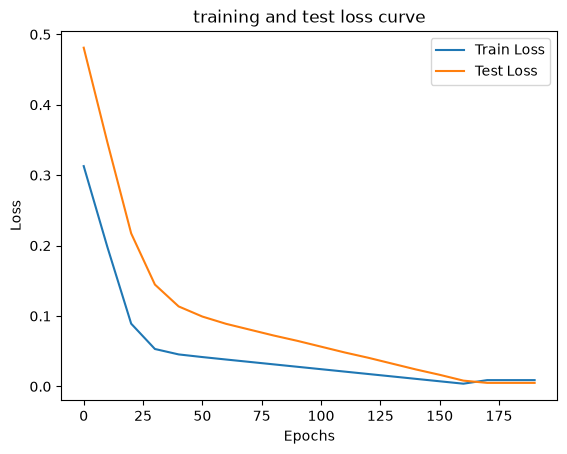

In [26]:
plt.plot(epoch_count,np.array(torch.tensor(loss_values).numpy()), label="Train Loss")
plt.plot(epoch_count,test_loss_values, label="Test Loss")
plt.title("training and test loss curve")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [27]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [28]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

In [29]:
weight , bias

(0.7, 0.3)

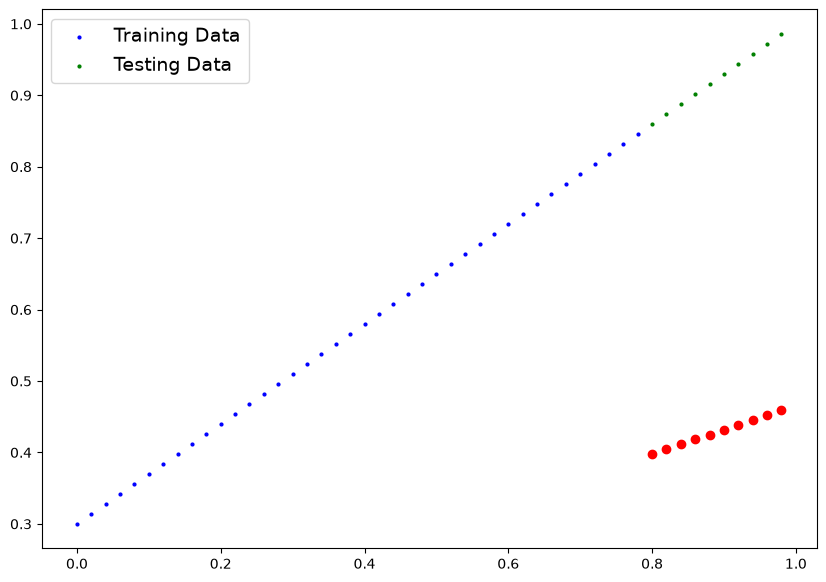

In [30]:
plot_prediction(predictions=y_preds)

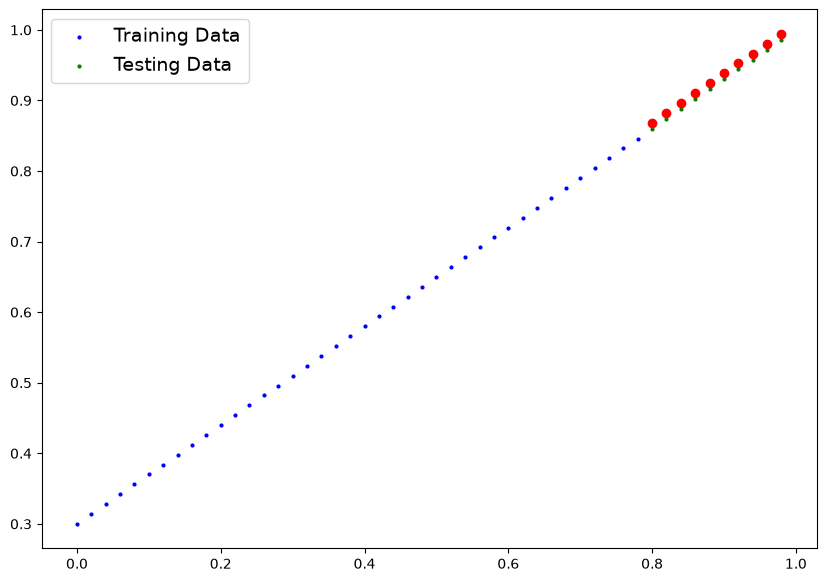

In [31]:
plot_prediction(predictions = y_preds_new)

### Saving a model in PyTorch

There are three main methods you should about for saving and loading models in PyTorch.

1. `torch.save()` - allows you save a PyTorch object in Python's pickle format
2. `torch.load()` - allows you load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` - this allows to load a model's saved state dictionary

In [32]:
#saving our model

from pathlib import Path

#1 create model directory
model_path = Path("models")
model_path.mkdir(parents=True,exist_ok=True)

#Create model save path
model_name = "pytorch_2_model.pth"
model_save_path = model_path / model_name

#saving the model state dict
torch.save(obj=model_0.state_dict(),f=model_save_path)

### Loading a PyTorch model

Since we saved our model's `state_dict()` rather the entire model, we'll create a new instance of our model class and load the saved `state_dict()` into that.

In [33]:
model_0.state_dict()


OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [34]:
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0 (this will update the new instance with updated params)
loaded_model_0.load_state_dict(torch.load(f=model_save_path))

<All keys matched successfully>

In [35]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [36]:
# Make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [37]:
y_preds == loaded_model_preds

tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False]])

In [38]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)
y_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [39]:
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])


### 6. Putting it all together

Let's go back through the steps above and see it all in one place.


In [40]:
# Import PyTorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.13.0+cpu'

In [41]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [42]:
# Create some data using the linear regression formula of y = weight * X + bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1) # without unsqueeze, errors will pop up
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [43]:

# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

40, 40, 10, 10

(40, 40, 10, 10)

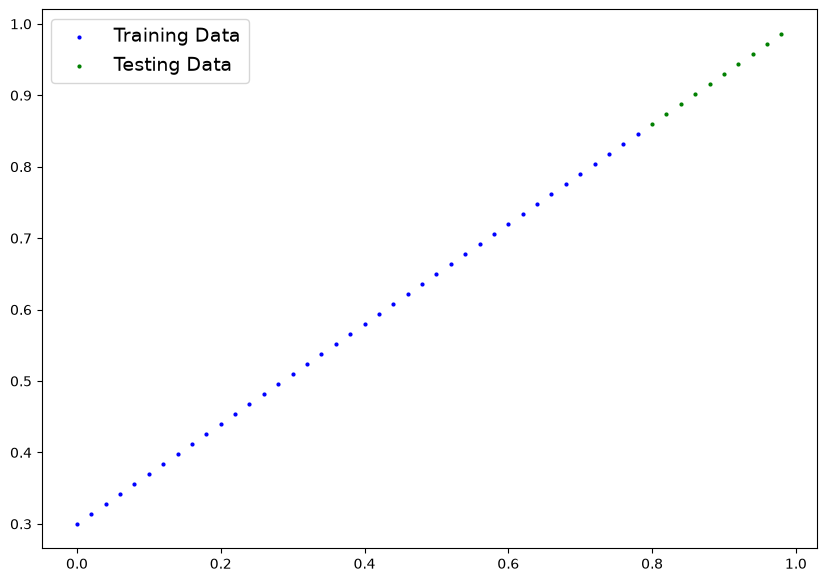

In [44]:
plot_prediction(X_train,y_train,X_test,y_test)

In [48]:
# Create a linear model by subclassing nn.Module
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()

        # Use nn.Linear() for creating model parameters
        self.linear_layer = nn.Linear(
            in_features=1,
            out_features=1
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

#Set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1 , model_1.state_dict()


(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

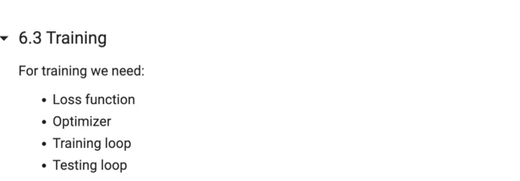

In [49]:
# Setup loss function
loss_fn = nn.L1Loss() # same as MAE

# Setup our optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                             lr=0.01)

In [56]:
# Let's write a training loop
torch.manual_seed(42)

epochs = 200

for epoch in range(epochs):
    model_1.train()

    #1 Forward pass
    y_pred = model_1(X_train)

    #2 Calculate the loss
    loss = loss_fn(y_pred,y_train)

    #3 Optimizer zero grad
    optimizer.zero_grad()

    #4 BackPropagation
    loss.backward()

    #5  Optimizer step
    optimizer.step()

###Testing 

    model_1.eval()

    with torch.inference_mode():
        test_pred = model_1(X_test)

        test_loss = loss_fn(test_pred,y_test)

    if epoch % 10 == 0:
        print(f"Epoch:{epoch},loss:{loss}, test loss:{test_loss}")


Epoch:0,loss:0.0012645035749301314, test loss:0.013801807537674904
Epoch:10,loss:0.0012645035749301314, test loss:0.013801807537674904
Epoch:20,loss:0.0012645035749301314, test loss:0.013801807537674904
Epoch:30,loss:0.0012645035749301314, test loss:0.013801807537674904
Epoch:40,loss:0.0012645035749301314, test loss:0.013801807537674904
Epoch:50,loss:0.0012645035749301314, test loss:0.013801807537674904
Epoch:60,loss:0.0012645035749301314, test loss:0.013801807537674904
Epoch:70,loss:0.0012645035749301314, test loss:0.013801807537674904
Epoch:80,loss:0.0012645035749301314, test loss:0.013801807537674904
Epoch:90,loss:0.0012645035749301314, test loss:0.013801807537674904
Epoch:100,loss:0.0012645035749301314, test loss:0.013801807537674904
Epoch:110,loss:0.0012645035749301314, test loss:0.013801807537674904
Epoch:120,loss:0.0012645035749301314, test loss:0.013801807537674904
Epoch:130,loss:0.0012645035749301314, test loss:0.013801807537674904
Epoch:140,loss:0.0012645035749301314, test lo

In [57]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [58]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
  y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

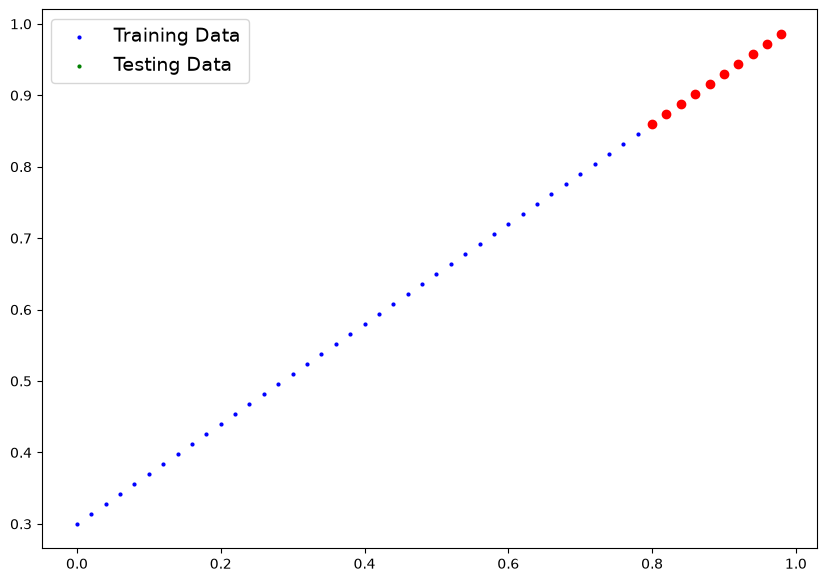

In [60]:
plot_prediction(predictions=y_preds)

In [64]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH
print(f"Saving Model to :{MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
           f=MODEL_SAVE_PATH)



Saving Model to :models\01_pytorch_workflow_model_1.pth
